Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [83]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

In [84]:
# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [85]:
timeseries = df['Passengers'].values.astype(np.float32)
print(timeseries[:5])

[112. 118. 132. 129. 121.]


Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [86]:
train, test = timeseries[:int(0.67*len(timeseries))], timeseries[int(0.67*len(timeseries)):]
print(train.shape, test.shape)

(96,) (48,)


**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [87]:
def create_dataset(dataset, lookback):
    X, y = [], []
    for i in range(len(dataset)-lookback):
        a = dataset[i:(i+lookback)]
        X.append(a)
        y.append(dataset[i + lookback : i + lookback + 1])
    return torch.tensor(X), torch.tensor(y)

In [88]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [89]:
class AirModel(nn.Module):
    def __init__(self, hidden_size, num_layers=1):
        super(AirModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.input_size = 1

        self.lstm = nn.LSTM(
            input_size=self.input_size,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            batch_first=True
        )
        self.linear = nn.Linear(self.hidden_size, 1)

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(-1)

        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])
        return out

In [90]:
m = AirModel(hidden_size=50, num_layers=1)
m(torch.tensor([[[112.]]]))

tensor([[-0.2526]], grad_fn=<AddmmBackward0>)

**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [91]:
train_df = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_df, batch_size=8, shuffle=True)

test_df = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_df, batch_size=8, shuffle=True)

**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [92]:
def train_model(hidden_size, train_loader, test_loader, n_iters=2000, val_every=100, lr=0.001):
    losses = []
    model = AirModel(hidden_size=hidden_size, num_layers=1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(n_iters):
        model.train()
        for X, y in train_loader:
            optimizer.zero_grad()
            y_pred = model(X)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        if epoch % val_every == 0:
            model.eval()
            with torch.no_grad():
                test_losses = []
                for X_batch, y_batch in test_loader:
                    y_test_pred = model(X_batch)
                    test_loss = criterion(y_test_pred, y_batch)
                    test_losses.append(test_loss.item())

                mean_test_loss = sum(test_losses) / len(test_losses)
                print(f"Epoch {epoch:4d} | Train Loss: {loss.item():.4f} | Test Loss: {mean_test_loss:.4f}")

    return model, losses

In [93]:
model, losses = train_model(hidden_size=50, train_loader=train_loader, test_loader=test_loader)

Epoch    0 | Train Loss: 48410.9922 | Test Loss: 178784.9609
Epoch  100 | Train Loss: 36099.5234 | Test Loss: 143879.3620
Epoch  200 | Train Loss: 23210.7500 | Test Loss: 119813.9818
Epoch  300 | Train Loss: 31424.9375 | Test Loss: 98462.6966
Epoch  400 | Train Loss: 14135.4170 | Test Loss: 81136.0801
Epoch  500 | Train Loss: 6834.4609 | Test Loss: 67555.7663
Epoch  600 | Train Loss: 6482.1201 | Test Loss: 55392.6087
Epoch  700 | Train Loss: 1091.4728 | Test Loss: 44923.8118
Epoch  800 | Train Loss: 484.5913 | Test Loss: 36474.6995
Epoch  900 | Train Loss: 1588.5784 | Test Loss: 29909.9512
Epoch 1000 | Train Loss: 723.6216 | Test Loss: 24867.9574
Epoch 1100 | Train Loss: 1576.6854 | Test Loss: 20379.9972
Epoch 1200 | Train Loss: 128.6211 | Test Loss: 17417.4281
Epoch 1300 | Train Loss: 996.4166 | Test Loss: 15489.7546
Epoch 1400 | Train Loss: 681.1434 | Test Loss: 13987.4345
Epoch 1500 | Train Loss: 882.5439 | Test Loss: 13349.2406
Epoch 1600 | Train Loss: 557.5254 | Test Loss: 11681.1

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

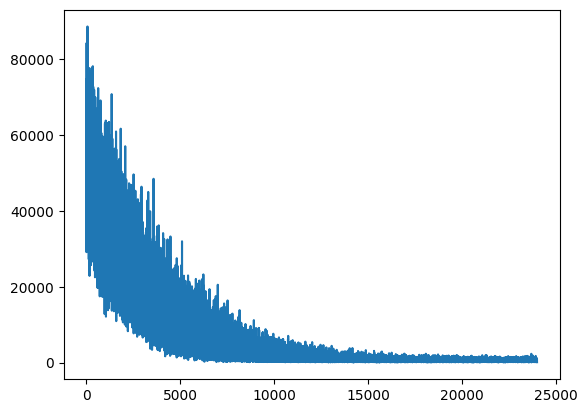

In [94]:
import matplotlib.pyplot as plt
#import matplotlib.ticker as ticker

plt.plot(losses)

Хоча на графіку видно, що модель обчається і похибка зменшується, все одно після після 2000 епох похибка завелика - модель помиляється приблизно на 100000 пасажирів на місяць.

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

In [95]:
def plot_predicts(timeseries, X_train, X_test):
  train_size = len(train)

  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(timeseries) * np.nan
      y_pred = model(X_train)
      y_pred = y_pred[:, -1]
      train_plot[lookback:train_size] = model(X_train)[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(timeseries) * np.nan
      test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]

  # Візуалізація результатів
  plt.plot(timeseries, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

/tmp/ipykernel_9321/3667713317.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = model(X_train)[:, -1]
/tmp/ipykernel_9321/3667713317.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]


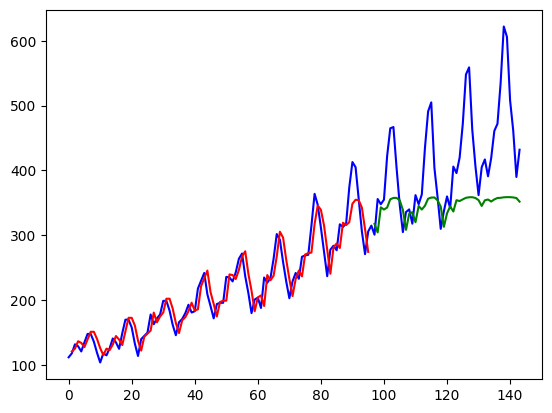

In [96]:
plot_predicts(timeseries, X_train, X_test)

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [97]:
model, losses = train_model(hidden_size=100, train_loader=train_loader, test_loader=test_loader)

Epoch    0 | Train Loss: 36798.4023 | Test Loss: 178063.3333
Epoch  100 | Train Loss: 21966.3398 | Test Loss: 113822.1497
Epoch  200 | Train Loss: 9973.0605 | Test Loss: 77977.8932
Epoch  300 | Train Loss: 2655.3835 | Test Loss: 55461.7103
Epoch  400 | Train Loss: 4454.7769 | Test Loss: 39029.8874
Epoch  500 | Train Loss: 3932.5332 | Test Loss: 29081.0475
Epoch  600 | Train Loss: 405.6758 | Test Loss: 22068.7423
Epoch  700 | Train Loss: 524.2122 | Test Loss: 16589.3563
Epoch  800 | Train Loss: 997.9891 | Test Loss: 13597.9321
Epoch  900 | Train Loss: 822.1569 | Test Loss: 11816.6134
Epoch 1000 | Train Loss: 744.5848 | Test Loss: 10180.8355
Epoch 1100 | Train Loss: 468.3193 | Test Loss: 9682.9611
Epoch 1200 | Train Loss: 462.4971 | Test Loss: 8709.1577
Epoch 1300 | Train Loss: 928.3231 | Test Loss: 8492.5123
Epoch 1400 | Train Loss: 262.4255 | Test Loss: 8208.8313
Epoch 1500 | Train Loss: 532.6808 | Test Loss: 7953.3978
Epoch 1600 | Train Loss: 105.8766 | Test Loss: 7636.6525
Epoch 1700

Хоча похибка і зменшилась, вона все одно залишилась дуже великою - модель дуже погано передбачає на нових даних.

Для покращення результатів моделі маштабуємо дані з допомогою MinMaxScaler

In [98]:
scaler = MinMaxScaler()
timeseries_scaled = scaler.fit_transform(timeseries.reshape(-1, 1)).flatten()

In [99]:
train_scaled, test_scaled = timeseries_scaled[:int(0.67*len(timeseries_scaled))], timeseries_scaled[int(0.67*len(timeseries_scaled)):]
print(train_scaled.shape, test_scaled.shape)

(96,) (48,)


In [100]:
lookback = 1
X_train_sc, y_train_sc = create_dataset(train_scaled, lookback=lookback)
X_test_sc, y_test_sc = create_dataset(test_scaled, lookback=lookback)
print(X_train_sc.shape, y_train_sc.shape)
print(X_test_sc.shape, y_test_sc.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


In [101]:
train_df_sc = TensorDataset(X_train_sc, y_train_sc)
train_loader_sc = DataLoader(train_df_sc, batch_size=8, shuffle=True)

test_df_sc = TensorDataset(X_test_sc, y_test_sc)
test_loader_sc = DataLoader(test_df_sc, batch_size=8, shuffle=True)

In [102]:
model, losses = train_model(hidden_size=50, train_loader=train_loader_sc, test_loader=test_loader_sc)

Epoch    0 | Train Loss: 0.0533 | Test Loss: 0.3879
Epoch  100 | Train Loss: 0.0023 | Test Loss: 0.0090
Epoch  200 | Train Loss: 0.0015 | Test Loss: 0.0087
Epoch  300 | Train Loss: 0.0021 | Test Loss: 0.0089
Epoch  400 | Train Loss: 0.0004 | Test Loss: 0.0087
Epoch  500 | Train Loss: 0.0011 | Test Loss: 0.0092
Epoch  600 | Train Loss: 0.0004 | Test Loss: 0.0088
Epoch  700 | Train Loss: 0.0013 | Test Loss: 0.0096
Epoch  800 | Train Loss: 0.0012 | Test Loss: 0.0096
Epoch  900 | Train Loss: 0.0018 | Test Loss: 0.0096
Epoch 1000 | Train Loss: 0.0022 | Test Loss: 0.0101
Epoch 1100 | Train Loss: 0.0026 | Test Loss: 0.0102
Epoch 1200 | Train Loss: 0.0017 | Test Loss: 0.0103
Epoch 1300 | Train Loss: 0.0018 | Test Loss: 0.0097
Epoch 1400 | Train Loss: 0.0012 | Test Loss: 0.0100
Epoch 1500 | Train Loss: 0.0018 | Test Loss: 0.0105
Epoch 1600 | Train Loss: 0.0027 | Test Loss: 0.0098
Epoch 1700 | Train Loss: 0.0023 | Test Loss: 0.0104
Epoch 1800 | Train Loss: 0.0019 | Test Loss: 0.0104
Epoch 1900 |

/tmp/ipykernel_9321/3667713317.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = model(X_train)[:, -1]
/tmp/ipykernel_9321/3667713317.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]


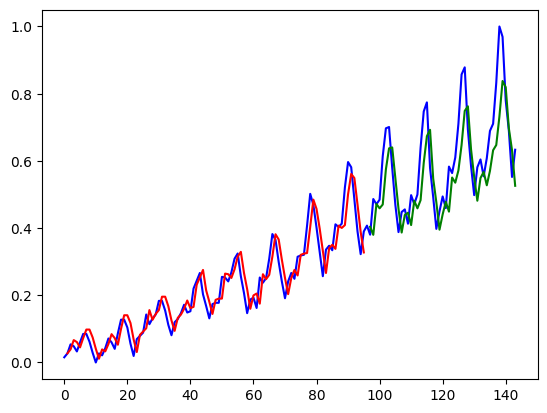

In [103]:
plot_predicts(timeseries_scaled, X_train_sc, X_test_sc)

Після маштабування похибка стала невеликою і з візуалізації бачимо, що модель добре навчилась на тренувальних даних і добре передбачає на даних, яких вона ще не бачила.